IMPORT REQUIRED LIBRARIES

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

LOADING MNIST DATASET

In [12]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Load MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=True)

DEFINING THE AUTOENCODER

In [13]:
# Create the autoencoder model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder: compress image to 32-dimensional vector
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU()
        )

        # Decoder: reconstruct image from 32-dimensional vector
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),  # Output in range [0, 1]
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Initialize the model
model = Autoencoder()


SET LOSS AND MARKDOWN FUNCTION

In [14]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

TRAIN THE AUTOENCODER

In [15]:
# Train the model
n_epochs = 10

for epoch in range(n_epochs):
    total_loss = 0
    for images, _ in train_loader:
        output = model(images)
        loss = criterion(output, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.0393
Epoch [2/10], Loss: 0.0190
Epoch [3/10], Loss: 0.0154
Epoch [4/10], Loss: 0.0140
Epoch [5/10], Loss: 0.0132
Epoch [6/10], Loss: 0.0126
Epoch [7/10], Loss: 0.0121
Epoch [8/10], Loss: 0.0117
Epoch [9/10], Loss: 0.0114
Epoch [10/10], Loss: 0.0111


VISUALIZE ORIGINAL vs RECONSTRUCTED IMAGE

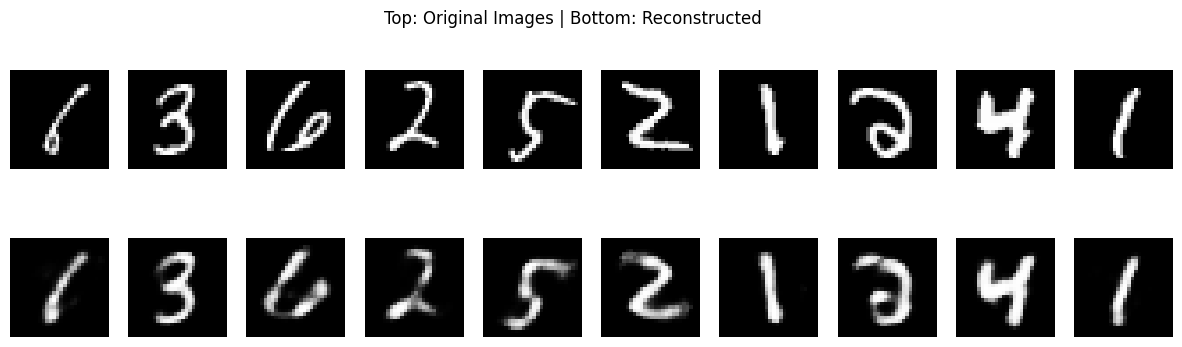

In [16]:
# Visualize original and reconstructed images
def show_reconstructed():
    images, _ = next(iter(test_loader))
    output = model(images)

    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(15, 4))
    for i in range(10):
        # Original images
        axes[0, i].imshow(images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        # Reconstructed images
        axes[1, i].imshow(output[i].detach().squeeze(), cmap='gray')
        axes[1, i].axis('off')

    plt.suptitle("Top: Original Images | Bottom: Reconstructed")
    plt.show()

show_reconstructed()


In [19]:
import torch.nn.functional as F

with torch.no_grad():
    reconstructed = model(images)

# Calculate MSE reconstruction error
mse = F.mse_loss(reconstructed, images)

print("Reconstruction error (MSE):", mse.item())


Reconstruction error (MSE): 0.01057253684848547
